In [10]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, auc
import gc
import re
import warnings
import os
import sys
import traceback

warnings.filterwarnings('ignore')

# Konfigurasi Tampilan
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Global Config
# Kosongkan jika file ada di folder yang sama dengan notebook.
# Jika di folder lain, isi misal: "C:/Users/Data/"
DATA_DIR = '' 
RANDOM_STATE = 42

print("Cell 1: Libraries Loaded & Configured.")

Cell 1: Libraries Loaded & Configured.


In [12]:
def safe_read_csv(filepath):
    """Mencoba membaca CSV dengan error handling."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"CRITICAL ERROR: File tidak ditemukan di path: {filepath}")
    
    try:
        df = pd.read_csv(filepath)
        print(f"   -> Successfully loaded {os.path.basename(filepath)} ({df.shape})")
        return df
    except MemoryError:
        print(f"CRITICAL ERROR: Memori penuh saat membaca {filepath}. Coba restart kernel.")
        sys.exit(1)
    except Exception as e:
        print(f"ERROR membaca {filepath}: {str(e)}")
        raise e

def reduce_mem_usage(df):
    """Mengurangi penggunaan memori dengan mengubah tipe data int/float."""
    try:
        start_mem = df.memory_usage().sum() / 1024**2
        for col in df.columns:
            col_type = df[col].dtype
            if col_type != object:
                c_min = df[col].min()
                c_max = df[col].max()
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)  
                else:
                    if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        df[col] = df[col].astype(np.float16)
                    elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
        
        end_mem = df.memory_usage().sum() / 1024**2
        print('   -> Memory optimized: {:.2f} MB to {:.2f} MB'.format(start_mem, end_mem))
        return df
    except Exception as e:
        print(f"WARNING: Reduce memory usage failed. Keeping original types.")
        return df

In [13]:
def process_bureau_data(path):
    print("\n--- Processing Bureau Data ---")
    try:
        bureau = safe_read_csv(path + 'bureau.csv')
        bb = safe_read_csv(path + 'bureau_balance.csv')
        
        # Aggregating Bureau Balance
        bb_cat = pd.get_dummies(bb, columns=['STATUS'])
        bb_agg = bb_cat.groupby('SK_ID_BUREAU').agg(['mean', 'sum'])
        bb_agg.columns = ['_'.join(col) for col in bb_agg.columns]
        
        # Merge
        bureau = bureau.merge(bb_agg, left_on='SK_ID_BUREAU', right_index=True, how='left')
        
        # Aggregating Bureau
        num_cols = bureau.select_dtypes(include=['float64', 'int64']).columns.tolist()
        for col in ['SK_ID_CURR', 'SK_ID_BUREAU']:
            if col in num_cols: num_cols.remove(col)
        
        bureau_agg = bureau.groupby('SK_ID_CURR')[num_cols].agg(['min', 'max', 'mean', 'sum'])
        bureau_agg.columns = ['BUREAU_' + '_'.join(col) for col in bureau_agg.columns]
        
        # Active loans count
        active_loans = bureau[bureau['CREDIT_ACTIVE'] == 'Active'].groupby('SK_ID_CURR').size()
        bureau_agg['BUREAU_ACTIVE_LOANS_COUNT'] = active_loans
        
        del bureau, bb, bb_agg
        gc.collect()
        return bureau_agg

    except Exception as e:
        print(f"ERROR in process_bureau_data: {e}")
        return None

def process_previous_applications(path):
    print("\n--- Processing Previous Applications ---")
    try:
        prev = safe_read_csv(path + 'previous_application.csv')
        pos = safe_read_csv(path + 'POS_CASH_balance.csv')
        ins = safe_read_csv(path + 'installments_payments.csv')
        cc = safe_read_csv(path + 'credit_card_balance.csv')
        
        # 1. POS CASH
        pos_agg = pos.groupby('SK_ID_PREV').agg({
            'MONTHS_BALANCE': ['max', 'mean', 'size'],
            'SK_DPD': ['max', 'mean'],
            'SK_DPD_DEF': ['max', 'mean']
        })
        pos_agg.columns = ['POS_' + '_'.join(col) for col in pos_agg.columns]
        
        # 2. INSTALLMENTS
        ins['AMT_INSTALMENT'] = ins['AMT_INSTALMENT'].replace(0, np.nan)
        ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
        ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
        ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
        ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
        
        ins_agg = ins.groupby('SK_ID_PREV').agg({
            'PAYMENT_PERC': ['mean', 'var'],
            'PAYMENT_DIFF': ['mean', 'var'],
            'DPD': ['max', 'mean', 'sum'],
            'DBD': ['max', 'mean', 'sum']
        })
        ins_agg.columns = ['INST_' + '_'.join(col) for col in ins_agg.columns]
        
        # 3. CREDIT CARD
        cc_agg = cc.groupby('SK_ID_PREV').agg({
            'AMT_BALANCE': ['mean', 'max'],
            'AMT_DRAWINGS_ATM_CURRENT': ['mean', 'sum'],
            'CNT_DRAWINGS_ATM_CURRENT': ['mean', 'sum'],
            'SK_DPD': ['mean', 'max']
        })
        cc_agg.columns = ['CC_' + '_'.join(col) for col in cc_agg.columns]
        
        # MERGING
        prev = prev.merge(pos_agg, on='SK_ID_PREV', how='left')
        prev = prev.merge(ins_agg, on='SK_ID_PREV', how='left')
        prev = prev.merge(cc_agg, on='SK_ID_PREV', how='left')
        
        # FINAL AGGREGATION
        num_cols = prev.select_dtypes(include=['float64', 'int64']).columns.tolist()
        for col in ['SK_ID_CURR', 'SK_ID_PREV']:
            if col in num_cols: num_cols.remove(col)
            
        prev_agg = prev.groupby('SK_ID_CURR')[num_cols].agg(['min', 'max', 'mean', 'sum'])
        prev_agg.columns = ['PREV_' + '_'.join(col) for col in prev_agg.columns]
        
        del prev, pos, ins, cc, pos_agg, ins_agg, cc_agg
        gc.collect()
        return prev_agg

    except Exception as e:
        print(f"ERROR in process_previous_applications: {e}")
        return None

In [14]:
def preprocess_final_data(train_df, test_df):
    print("\n--- Preprocessing & Cleaning ---")
    try:
        # Encoding
        train_len = len(train_df)
        test_df['TARGET'] = np.nan
        df_all = pd.concat([train_df, test_df], sort=False)
        
        print("   -> One Hot Encoding...")
        df_all = pd.get_dummies(df_all)
        # Hapus karakter aneh di nama kolom agar LightGBM tidak error
        df_all = df_all.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
        
        train_df = df_all.iloc[:train_len, :]
        test_df = df_all.iloc[train_len:, :]
        
        train_labels = train_df['TARGET']
        train_df = train_df.drop('TARGET', axis=1)
        test_df = test_df.drop('TARGET', axis=1)
        
        # Handling Inf
        print("   -> Handling Infinite & Null values...")
        train_df = train_df.replace([np.inf, -np.inf], np.nan)
        test_df = test_df.replace([np.inf, -np.inf], np.nan)
        
        # Imputation (Median)
        print("   -> Imputing missing values...")
        imputer = SimpleImputer(strategy='median')
        imputer.fit(train_df)
        
        train_imputed = pd.DataFrame(imputer.transform(train_df), columns=train_df.columns)
        # test_imputed = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns) # Opsional jika mau submit
        
        # Scaling (Hanya untuk Logistic Regression)
        print("   -> Scaling data...")
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaler.fit(train_imputed)
        train_scaled = pd.DataFrame(scaler.transform(train_imputed), columns=train_imputed.columns)
        
        return train_imputed, train_scaled, train_labels

    except Exception as e:
        print(f"ERROR in Preprocessing: {e}")
        traceback.print_exc()
        return None, None, None

In [15]:
def train_model_safe(model_type, X_train, y_train, X_val, y_val):
    print(f"\n--- Training {model_type} ---")
    try:
        if model_type == 'Logistic Regression':
            model = LogisticRegression(C=0.0001, class_weight='balanced', random_state=RANDOM_STATE)
            model.fit(X_train, y_train)
            pred = model.predict_proba(X_val)[:, 1]
            auc_score = roc_auc_score(y_val, pred)
            print(f"   >> Logistic Regression ROC AUC: {auc_score:.5f}")
            return model
            
        elif model_type == 'LightGBM':
            train_set = lgb.Dataset(X_train, label=y_train)
            valid_set = lgb.Dataset(X_val, label=y_val)
            
            params = {
                'objective': 'binary', 'metric': 'auc', 'is_unbalance': True,
                'boosting': 'gbdt', 'num_leaves': 31, 'feature_fraction': 0.5,
                'bagging_fraction': 0.5, 'bagging_freq': 20, 'learning_rate': 0.05,
                'verbose': -1, 'seed': RANDOM_STATE
            }
            
            # Callbacks untuk early stopping dan logging
            callbacks = [lgb.early_stopping(100), lgb.log_evaluation(50)]
            
            model = lgb.train(params, train_set, num_boost_round=1000, 
                              valid_sets=[valid_set], callbacks=callbacks)
            
            print(f"   >> LightGBM Best Score: {model.best_score['valid_0']['auc']:.5f}")
            return model
            
    except Exception as e:
        print(f"ERROR during training {model_type}: {e}")
        return None

In [16]:
def plot_additional_insights(df_raw, model, X_val, y_val):
    """
    df_raw: Dataframe mentah (belum di-scale) untuk visualisasi distribusi yang manusiawi.
    model: Model LightGBM yang sudah dilatih.
    X_val, y_val: Data validasi yang sudah diproses untuk kurva ROC.
    """
    print("\n--- Generating Business Insights Visualizations ---")
    
    # 1. Target Distribution
    try:
        plt.figure(figsize=(6, 4))
        ax = sns.countplot(x='TARGET', data=df_raw, palette='viridis')
        plt.title('Distribution of Repayment Abilities\n(0: Non-Default, 1: Default)')
        
        total = len(df_raw)
        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2 - 0.05
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom')
        plt.show()
    except Exception as e: print(f"Skip Plot 1: {e}")

    # 2. Age Risk Profile
    try:
        if 'DAYS_BIRTH' in df_raw.columns:
            df_viz = df_raw[['DAYS_BIRTH', 'TARGET']].copy()
            df_viz['AGE_YEARS'] = abs(df_viz['DAYS_BIRTH']) / 365
            df_viz['AGE_GROUP'] = pd.cut(df_viz['AGE_YEARS'], bins=np.linspace(20, 70, 11))
            
            plt.figure(figsize=(10, 5))
            age_risk = df_viz.groupby('AGE_GROUP')['TARGET'].mean() * 100 
            sns.barplot(x=age_risk.index.astype(str), y=age_risk.values, palette='Reds_r')
            plt.title('Risk Profile by Age Group\n(Younger Clients have Higher Default Rate)')
            plt.ylabel('Default Rate (%)')
            plt.xticks(rotation=45)
            plt.show()
    except Exception as e: print(f"Skip Plot 2: {e}")
        
    # 3. External Sources Heatmap
    try:
        cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']
        cols = [c for c in cols if c in df_raw.columns]
        if len(cols) > 1:
            plt.figure(figsize=(6, 5))
            sns.heatmap(df_raw[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
            plt.title('Correlation: External Sources vs Target')
            plt.show()
    except Exception as e: print(f"Skip Plot 3: {e}")

    # 4. ROC Curve
    try:
        y_pred = model.predict(X_val, num_iteration=model.best_iteration)
        fpr, tpr, _ = roc_curve(y_val, y_pred)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - LightGBM')
        plt.legend(loc="lower right")
        plt.show()
    except Exception as e: print(f"Skip Plot 4: {e}")

STARTING PIPELINE...
   -> Successfully loaded application_train.csv ((307511, 122))
   -> Successfully loaded application_test.csv ((48744, 121))

--- Processing Bureau Data ---
   -> Successfully loaded bureau.csv ((1716428, 17))
   -> Successfully loaded bureau_balance.csv ((27299925, 3))

--- Processing Previous Applications ---
   -> Successfully loaded previous_application.csv ((1670214, 37))
   -> Successfully loaded POS_CASH_balance.csv ((10001358, 8))
   -> Successfully loaded installments_payments.csv ((13605401, 8))
   -> Successfully loaded credit_card_balance.csv ((3840312, 23))

--- Merging Data ---
   -> Memory optimized: 983.03 MB to 328.75 MB
   -> Memory optimized: 155.45 MB to 51.41 MB

--- Preprocessing & Cleaning ---
   -> One Hot Encoding...
   -> Handling Infinite & Null values...
   -> Imputing missing values...
   -> Scaling data...

--- Splitting Data ---

--- Training Logistic Regression ---
   >> Logistic Regression ROC AUC: 0.72538

--- Training LightGBM --

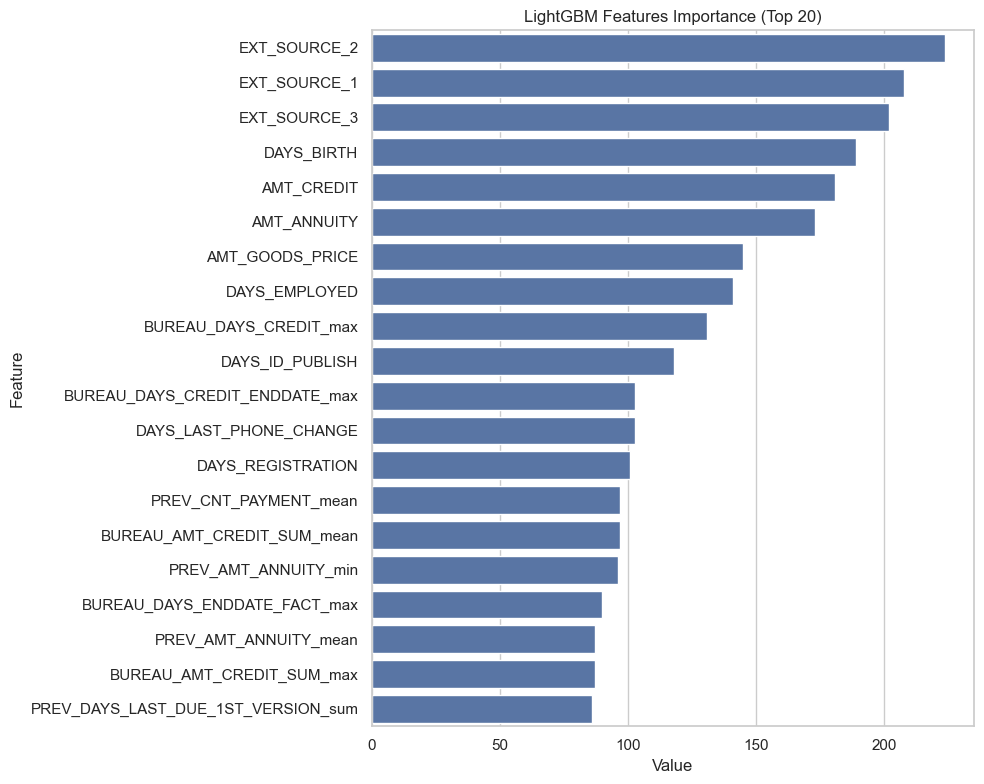


--- Generating Business Insights Visualizations ---


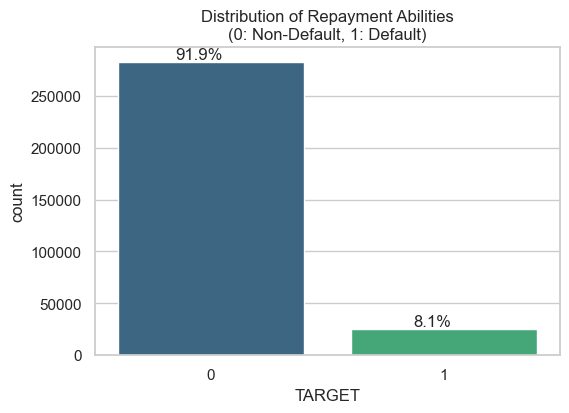

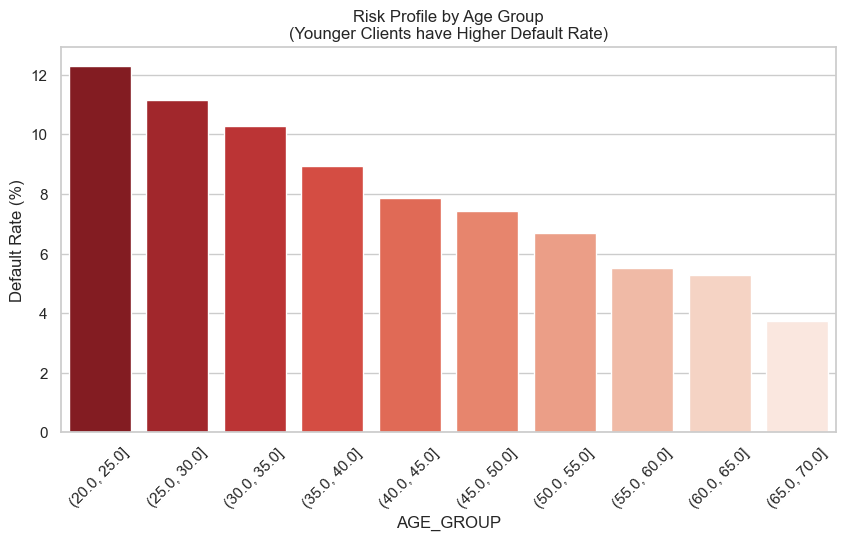

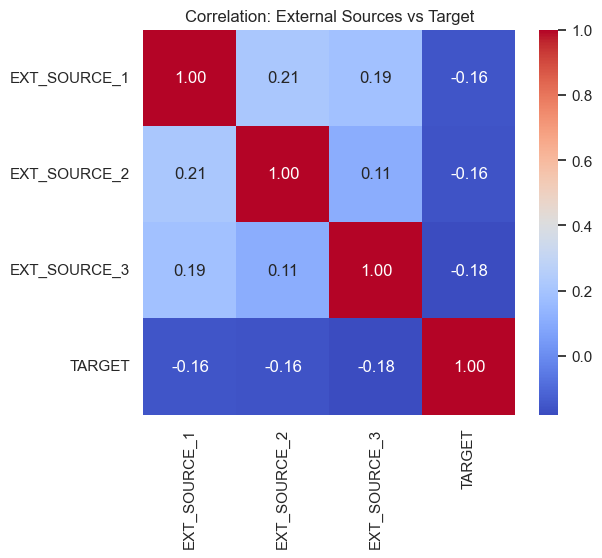

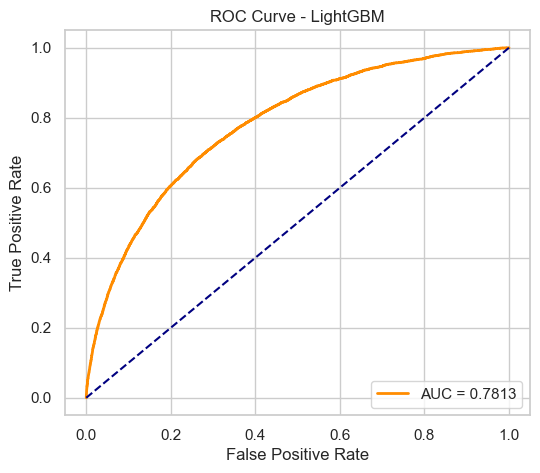


PIPELINE COMPLETED SUCCESSFULLY.


In [17]:
def main():
    print("STARTING PIPELINE...")
    
    # 1. Load Main Data
    try:
        app_train = safe_read_csv(DATA_DIR + 'application_train.csv')
        app_test = safe_read_csv(DATA_DIR + 'application_test.csv')
    except Exception as e:
        print(f"Critical Error loading main files: {e}")
        return

    # 2. Feature Engineering
    bureau_agg = process_bureau_data(DATA_DIR)
    prev_agg = process_previous_applications(DATA_DIR)
    
    if bureau_agg is None or prev_agg is None:
        print("STOPPING: Feature Engineering failed.")
        return

    # Merging
    print("\n--- Merging Data ---")
    try:
        app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')
        app_train = app_train.merge(prev_agg, on='SK_ID_CURR', how='left')
        
        app_test = app_test.merge(bureau_agg, on='SK_ID_CURR', how='left')
        app_test = app_test.merge(prev_agg, on='SK_ID_CURR', how='left')
        
        # PENTING: Simpan kolom visualisasi SEBELUM Preprocessing mengubah angka
        viz_cols = ['TARGET', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
        viz_cols = [c for c in viz_cols if c in app_train.columns]
        app_train_viz = app_train[viz_cols].copy() # Copy data mentah untuk grafik
        
        del bureau_agg, prev_agg
        gc.collect()
        
        # Optimize Memory
        app_train = reduce_mem_usage(app_train)
        app_test = reduce_mem_usage(app_test)
        
    except Exception as e:
        print(f"Error during merging: {e}")
        return

    # 3. Preprocessing
    X_imputed, X_scaled, y = preprocess_final_data(app_train, app_test)
    
    if X_imputed is None: return

    # 4. Split Data
    print("\n--- Splitting Data ---")
    # Logistic Regression butuh data yang di-Scale (X_scaled)
    X_train_sc, X_val_sc, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)
    
    # LightGBM lebih suka data asli/imputed saja (X_imputed)
    X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(X_imputed, y, test_size=0.2, random_state=RANDOM_STATE)

    # 5. Modeling
    # A. Logistic Regression (Baseline)
    model_lr = train_model_safe('Logistic Regression', X_train_sc, y_train, X_val_sc, y_val)
    
    # B. LightGBM (Champion)
    model_lgbm = train_model_safe('LightGBM', X_train_lgb, y_train_lgb, X_val_lgb, y_val_lgb)

    # 6. Insight & Visualization
    if model_lgbm:
        # Tampilkan Grafik Feature Importance
        print("\n--- Feature Importance ---")
        feature_imp = pd.DataFrame(sorted(zip(model_lgbm.feature_importance(), X_train_lgb.columns)), columns=['Value','Feature'])
        plt.figure(figsize=(10, 8))
        sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
        plt.title('LightGBM Features Importance (Top 20)')
        plt.tight_layout()
        plt.show()
        
        # Tampilkan 4 Grafik Bisnis Tambahan
        # Kirimkan data viz mentah, model lgbm, dan data validasi lgbm
        plot_additional_insights(app_train_viz, model_lgbm, X_val_lgb, y_val_lgb)
    
    print("\nPIPELINE COMPLETED SUCCESSFULLY.")

if __name__ == "__main__":
    main()